<a href="https://colab.research.google.com/github/Pavan2006-22/ITA_ASSIGNMENT_IPM06038/blob/main/ITA_PROJECT_IPM06038.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

# Set plot style
sns.set(style='whitegrid')
%matplotlib inline

In [2]:
# 1. Load and Inspect the Dataset
# The provided file is a gzipped JSON (JSON lines format)
df = pd.read_json('/content/Luxury_Beauty_5.json.gz', lines=True)

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
display(df.head())
display(df.describe())

Dataset Shape: (34278, 12)

Column Names: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'image']

Missing Values:
 overall               0
verified              0
reviewTime            0
reviewerID            0
asin                  0
style             17437
reviewerName          0
reviewText           13
summary              15
unixReviewTime        0
vote              27746
image             33661
dtype: int64


,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,5,True,"01 5, 2018",A2HOI48JK8838M,B00004U9V2,{'Size:': ' 0.9 oz.'},DB,This handcream has a beautiful fragrance. It d...,Beautiful Fragrance,1515110400,NaN,NaN
1,5,True,"04 5, 2017",A1YIPEY7HX73S7,B00004U9V2,{'Size:': ' 3.5 oz.'},Ajaey,"wonderful hand lotion, for seriously dry skin,...",wonderful hand lotion,1491350400,NaN,NaN
2,5,True,"03 27, 2017",A2QCGHIJ2TCLVP,B00004U9V2,{'Size:': ' 250 g'},D. Jones,"Best hand cream around. Silky, thick, soaks i...",Best hand cream around,1490572800,NaN,NaN
3,5,True,"03 20, 2017",A2R4UNHFJBA6PY,B00004U9V2,{'Size:': ' 3.5 oz.'},Amazon Customer,Thanks!!,Five Stars,1489968000,NaN,NaN
4,5,True,"02 28, 2017",A2QCGHIJ2TCLVP,B00004U9V2,{'Size:': ' 0.9 oz.'},D. Jones,Great hand lotion. Soaks right in and leaves ...,Great hand lotion!,1488240000,NaN,NaN


,overall,unixReviewTime,vote
count,34278.00000,3.427800e+04,6532.000000
mean,4.28616,1.445171e+09,7.315677
std,1.03736,4.962381e+07,21.295736
min,1.00000,1.127174e+09,2.000000
25%,4.00000,1.411430e+09,2.000000
50%,5.00000,1.448410e+09,3.000000
75%,5.00000,1.484093e+09,6.000000
max,5.00000,1.537747e+09,686.000000


In [3]:
# 2 & 3. Feature Engineering
# Extract relevant features and create new ones

# Review Length
df['reviewText'] = df['reviewText'].fillna('')
df['review_length'] = df['reviewText'].apply(len)

# Helpful Votes - usually structured as [votes, total] or just a count in some versions
# In this dataset, 'vote' is often a string with commas for numbers
def clean_vote(v):
    try:
        return int(str(v).replace(',', ''))
    except:
        return 0

df['helpful_votes'] = df['vote'].apply(clean_vote)

# Sentiment Score using TextBlob
print("Calculating sentiment scores (this may take a moment)...")
df['sentiment_score'] = df['reviewText'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Select key numeric features for clustering
features = ['overall', 'review_length', 'sentiment_score', 'helpful_votes']
X_numeric = df[features].fillna(0)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

display(df[features + ['reviewText']].head())

Calculating sentiment scores (this may take a moment)...


,overall,review_length,sentiment_score,helpful_votes,reviewText
0,5,125,0.300000,0,This handcream has a beautiful fragrance. It d...
1,5,187,0.271250,0,"wonderful hand lotion, for seriously dry skin,..."
2,5,85,0.283333,0,"Best hand cream around. Silky, thick, soaks i..."
3,5,8,0.312500,0,Thanks!!
4,5,95,0.503810,0,Great hand lotion. Soaks right in and leaves ...


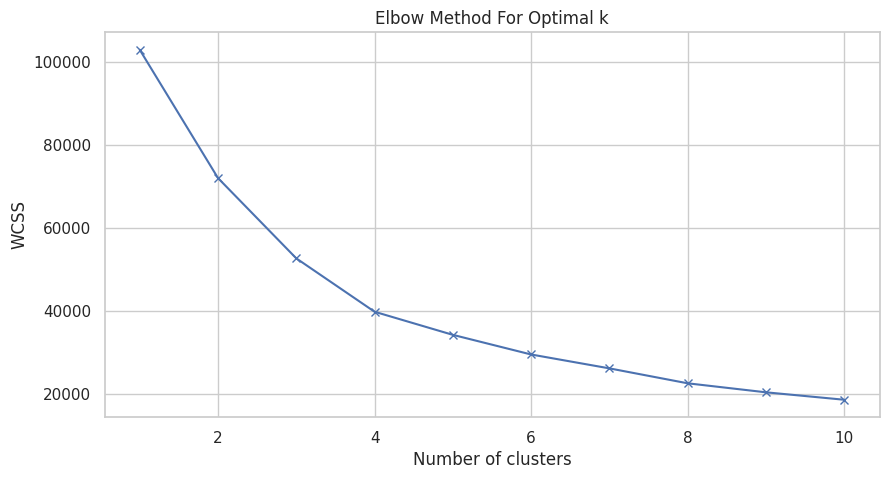

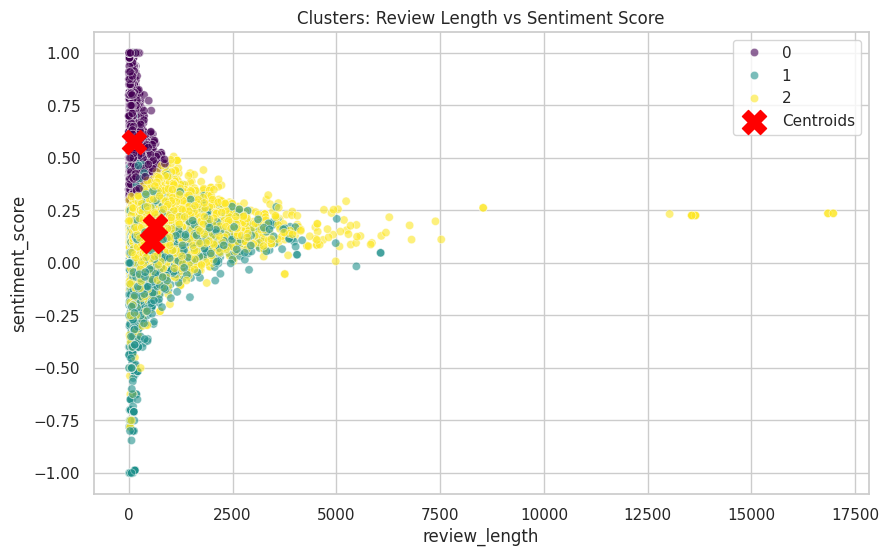

In [4]:
# 4. K-Means Clustering & Elbow Method
wcss = []
K_range = range(1, 11)
for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal k')
plt.show()

# Optimal k (let's use 3 for distinct segmentation)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize Clusters (Review Length vs Sentiment)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='review_length', y='sentiment_score', hue='cluster', palette='viridis', alpha=0.6)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 1], centroids[:, 2], s=300, c='red', marker='X', label='Centroids')
plt.title('Clusters: Review Length vs Sentiment Score')
plt.legend()
plt.show()

In [5]:
# 5. Create Target Variable
# We label clusters with low helpfulness, extreme sentiment, or short lengths as suspicious
# Finding the cluster with the lowest helpful_votes mean or extreme behavior
cluster_stats = df.groupby('cluster')[features].mean()
print("Cluster Profile:\n", cluster_stats)

# Logic: Identify cluster with highest 'fake' characteristics
# (e.g., short reviews + high/low rating + low helpfulness)
suspicious_cluster = cluster_stats['helpful_votes'].idxmin()
df['fake_review'] = (df['cluster'] == suspicious_cluster).astype(int)

print(f"\nDetected {df['fake_review'].sum()} potential fake reviews in Cluster {suspicious_cluster}")

Cluster Profile:
           overall  review_length  sentiment_score  helpful_votes
cluster                                                         
0        4.860447     120.624436         0.574526            0.0
1        2.421127     567.357053         0.104284            0.0
2        4.640594     634.112528         0.174517            0.0

Detected 8864 potential fake reviews in Cluster 0


In [6]:
# 6 & 7. Logistic Regression Model
X = X_numeric
y = df['fake_review']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

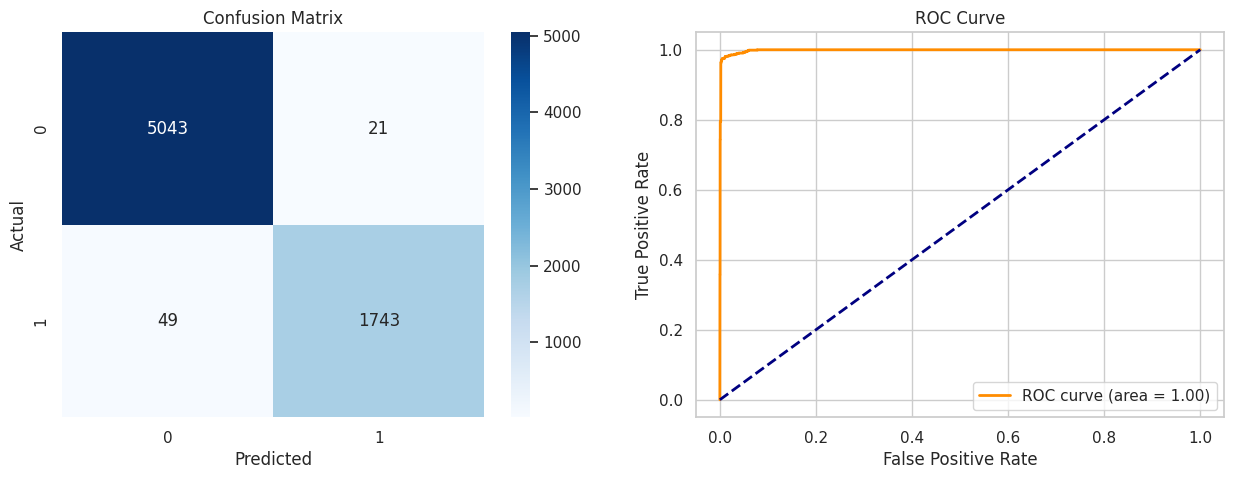

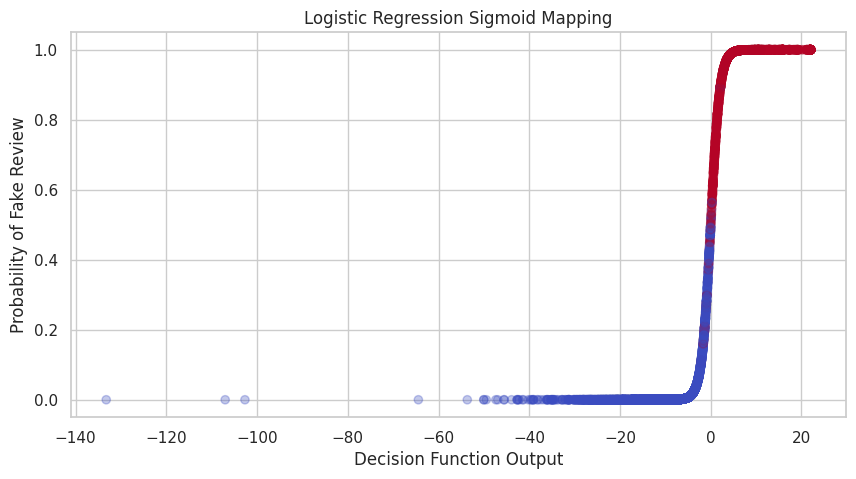

--- Final Results ---
Model Accuracy: 0.9898
ROC-AUC Score: 0.9986

Total Distribution of Detected Reviews:
fake_review
Genuine    25414
Fake        8864
Name: count, dtype: int64

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      5064
           1       0.99      0.97      0.98      1792

    accuracy                           0.99      6856
   macro avg       0.99      0.98      0.99      6856
weighted avg       0.99      0.99      0.99      6856



In [7]:
# 8. Visualization & Final Output
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('ROC Curve')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc="lower right")
plt.show()

# Logistic Sigmoid Curve Visualization (1D representation using a decision score)
plt.figure(figsize=(10, 5))
decision_scores = model.decision_function(X_test)
plt.scatter(decision_scores, y_prob, c=y_test, cmap='coolwarm', alpha=0.3)
plt.title('Logistic Regression Sigmoid Mapping')
plt.xlabel('Decision Function Output')
plt.ylabel('Probability of Fake Review')
plt.show()

# Final Numerical Output
print("--- Final Results ---")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nTotal Distribution of Detected Reviews:")
print(df['fake_review'].value_counts().rename({0: 'Genuine', 1: 'Fake'}))
print("\nClassification Report:\n", classification_report(y_test, y_pred))